# 202235203 고수호
# **4week - titanic.csv 데이터에 대한 Classification**
데이터를 '**Feature Selection** 유/무', '**결측치** 대체/제거' 등의 전략을 통해 나누어 전략간의 **정확도**, **혼돈 행렬** 평가.


# **# 데이터 세트 불러오기**
`import pandas as pd` : 데이터를 표(Table) 형태로 다루기 위한 **Pandas** 라이브러리.  
`import numpy as np` : 수치 계산 및 행렬 연산을 위한 **NumPy** 라이브러리.  
`import seaborn as sns` : 데이터를 읽기 쉽게 시각화하는 **Seaborn** 라이브러리.  
`path = '/content/drive/MyDrive/Colab Notebooks/4week/titanic.csv'` : 데이터 파일이 저장된 경로를 문자열 변수 '**path**'에 저장.  
`df = pd.read_csv(path)` : 읽어온 데이터는 데이터프레임 형태로 변수 '**df**'에 저장.  



In [98]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
path = '/content/drive/MyDrive/Colab Notebooks/4week/titanic.csv'
df = pd.read_csv(path)

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


# **# 라벨 인코딩과 상관관계 확인**
```
from sklearn.preprocessing import LabelEncoder
df_encoded = df.copy()
```
* **LabelEncoder** : 문자열 데이터를 모델이 이해할 수 있는 숫자로 변환하는 도구.
* **df_encoded** : 원본 데이터를 보존하기 위해 복사본 생성.

```
le = LabelEncoder()
for col in df_encoded.columns:
  if df_encoded[col].dtype == 'object':
      df_encoded[col] = le.fit_transform(df_encoded[col])
```
* **역할** : 데이터의 모든 Column을 검사하여 데이터 타입이 **object(문자열)** 인 경우에만 숫자로 변환.
* **예시** :
  * Sex : female -> 0, male -> 1
  * Embarked : C -> 0, Q -> 1, S -> 2
```
df_corr = df_encoded.corr()
plt.figure(figsize=(10,10))
sns.set(font_scale = 0.8)
sns.heatmap(df_corr, annot=True, cbar=False)
```
* **corr()** : 모든 숫자형 변수 쌍 간의 **피어슨 상관계수**를 계산하여 행렬 형태로 변환.
* **figsize=(10,10)** : 그래프의 크기를 가로세로 10인치로 설정.
* **sns.set(font_scale=0.8)** : 글자 크기를 0.8로 설정.
* **sns.heatmap(...)** : 상관계수 행렬을 색상으로 시각화.
  * **annot=True** : 각 칸에 실제 상관계수 숫자를 표시.
  * **cbar=False** : 우측의 수치별 색상 막대를 제거.


<Axes: >

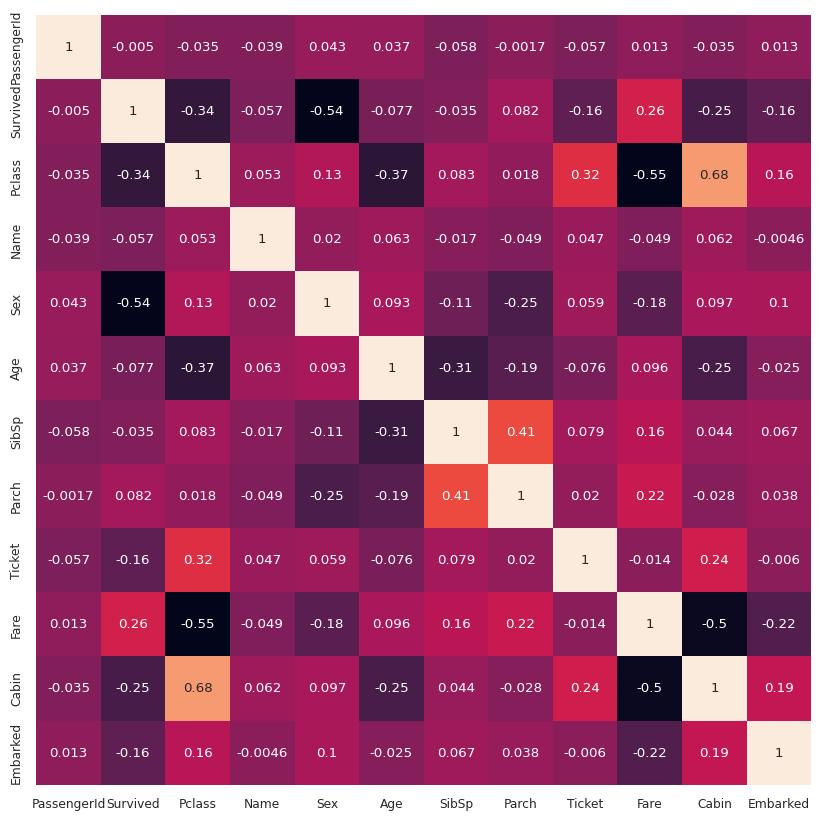

In [99]:
from sklearn.preprocessing import LabelEncoder
df_encoded = df.copy()

le = LabelEncoder()
for col in df_encoded.columns:
  if df_encoded[col].dtype == 'object':
      df_encoded[col] = le.fit_transform(df_encoded[col])

df_corr = df_encoded.corr()
plt.figure(figsize=(10,10))
sns.set(font_scale = 0.8)
sns.heatmap(df_corr, annot=True, cbar=False)

# **# 결측치 확인**
`df_encoded.isnull().sum()`
* **isnull()** : 각 데이터 칸이 비어있는지 채워져 있는지 판별.
* **.sum()** : 채워져 있는 칸의 개수를 합산.

In [100]:
df_encoded.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


# **# 결측치 처리 전략(대체)**
```
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

df_mean = df_encoded.copy()
df_median = df_encoded.copy()
df_most = df_encoded.copy()
df_iter = df_encoded.copy()
```
* **IterativeImputer** : 다른 변수들간의 관계를 계산하여 빈값을 예측하는 도구.
* **df_mean** : 결측치를 평균값으로 채운 df.
* **df_median** : 결측치를 중앙값으로 채운 df.
* **df_most** : 결측치를 최빈값으로 채운 df.
* **df_iter** : 결측치를 컬럼들간의 특징을 통해 예측하여 채운 df.


In [101]:
from sklearn.impute import SimpleImputer
from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer

df_mean = df_encoded.copy()
df_median = df_encoded.copy()
df_most = df_encoded.copy()
df_iter = df_encoded.copy()

df_mean['Age'] = df_mean['Age'].fillna(df_mean['Age'].mean()) # Age의 결측치를 평균값으로
df_median['Age'] = df_median['Age'].fillna(df_median['Age'].median()) # Age의 결측치를 중앙값으로
df_most['Age'] = df_most['Age'].fillna(df_median['Age'].median()) # Age의 결측치를 최빈값으로

it_imp = IterativeImputer(random_state=0) # 결측치를 예측해서 채워줄 인공지능 도구(it_imp) 준비
df_iter[['Age', 'Pclass', 'SibSp', 'Parch', 'Fare']] = it_imp.fit_transform( # Age의 결측치를 추정값으로(Age와 다른 컬럼들의 관계를 통한 추측)
    df_iter[['Age', 'Pclass', 'SibSp', 'Parch', 'Fare']] # IterativeImputer는 숫자 데이터만 이해 가능하기에 숫자형 컬럼만 모아서 처리
)

# **# 결측치 처리 전략(제거)**
```
df_encoded = df_encoded.dropna()
```
* **dropna()** : 데이터프레임의 모든 행을 검사하여 **결측치(NaN)**가 하나라도 포함된 행이 있다면 해당 행 전체를 삭제.


In [102]:
df_encoded= df_encoded.dropna()
df_encoded.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


# **# 결측치 처리 전략에 따른 데이터 전처리와 Feature Selection**
`.drop(['Survived','PassengerId','Name','Ticket','Cabin','Embarked']`

**타겟 변수** : **'Survived'**  
**PassengerId** : 상관계수(0.005)  
**Name** : 상관계수(0.057), 문자열데이터  
**Ticket** : 상관계수(0.16), 문자열데이터  
**Cabin** : 상관계수(0.25), 대부분의 값이 결측치, 문자열데이터  
**Embarked** : 상관계수(0.16), 문자열데이터  


In [103]:
y = df_encoded['Survived']
y_fs = df_encoded['Survived']
y_mean = df_mean['Survived']
y_median = df_median['Survived']
y_most = df_most['Survived']
y_iter = df_iter['Survived']

X = df_encoded.drop(['Survived'],axis=1)
X_fs = df_encoded.drop(['Survived','PassengerId','Name','Ticket','Cabin','Embarked'], axis = 1)
X_mean = df_mean.drop(['Survived','PassengerId','Name','Ticket','Cabin','Embarked'], axis = 1)
X_median = df_median.drop(['Survived','PassengerId','Name','Ticket','Cabin','Embarked'], axis = 1)
X_most = df_most.drop(['Survived','PassengerId','Name','Ticket','Cabin','Embarked'], axis = 1)
X_iter = df_iter.drop(['Survived','PassengerId','Name','Ticket','Cabin','Embarked'], axis = 1)

# **# 데이터셋 분리 (Training & Test Set)**
`from sklearn.model_selection import train_test_split` : 데이터를 나누기 위한 사이킷런의 함수.  
`test_size=0.25` : 전체 데이터의 **25%** 를 평가용(Test)으로, **75%** 를 학습용(Train)으로 설정.  
`random_state=0` : 실행할 때마다 동일한 결과가 나오도록 난수 시드 고정.

In [104]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.25,random_state=0)
X_train_fs, X_test_fs, y_train_fs, y_test_fs = train_test_split(X_fs, y_fs,test_size=0.25,random_state=0)
X_train_mean, X_test_mean, y_train_mean, y_test_mean = train_test_split(X_mean, y_mean,test_size=0.25,random_state=0)
X_train_median, X_test_median, y_train_median, y_test_median = train_test_split(X_median, y_median,test_size=0.25,random_state=0)
X_train_most, X_test_most, y_train_most, y_test_most = train_test_split(X_most, y_most,test_size=0.25,random_state=0)
X_train_iter, X_test_iter, y_train_iter, y_test_iter = train_test_split(X_iter, y_iter,test_size=0.25,random_state=0)


# **# 전략별 학습 및 평가 1 - 기본 DF(df)**
**Feature Selection을 하지 않고 결측치를 모두 제거한 DF**   

**Logistic Regression accuracy** : 78%   
**Decision Tree accuracy** : 76%   
**Random Forest accuracy** : 81%  
**kNN accuracy** : 63%  

In [105]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn import metrics

le = LabelEncoder()

clf_lr = LogisticRegression(random_state=0)
clf_dt = DecisionTreeClassifier(random_state=0)
clf_rf = RandomForestClassifier(random_state=0)
knn = KNeighborsClassifier(n_neighbors=6)

clf_lr.fit(X_train, y_train)
clf_dt.fit(X_train, y_train)
clf_rf.fit(X_train, y_train)
knn.fit(X_train, y_train)

pred_lr = clf_lr.predict(X_test)
pred_dt = clf_dt.predict(X_test)
pred = clf_rf.predict(X_test)
pred_y = knn.predict(X_test)

print ("\n--- Logistic Regression Classifier ---")
print (accuracy_score(y_test, pred_lr))
print (confusion_matrix(y_test, pred_lr))

print ("\n--- Decision Tree Classifier ---")
print (accuracy_score(y_test, pred_dt))
print (confusion_matrix(y_test, pred_dt))

print ("\n--- Random Forest ---")
print (accuracy_score(y_test,pred))
print (confusion_matrix(y_test, pred))

print ("\n--- kNN ---")
print (accuracy_score(y_test,pred_y))
print (confusion_matrix(y_test, pred_y))

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(



--- Logistic Regression Classifier ---
0.7821229050279329
[[86 17]
 [22 54]]

--- Decision Tree Classifier ---
0.7597765363128491
[[79 24]
 [19 57]]

--- Random Forest ---
0.8100558659217877
[[87 16]
 [18 58]]

--- kNN ---
0.6312849162011173
[[84 19]
 [47 29]]


# **# 전략별 학습 및 평가 2 - Feature Selection DF(df_fs)**
**Feature Selection을 하고 결측치를 모두 제거한 DF**  
**Logistic Regression accuracy** : 82%   
**Decision Tree accuracy** : 80%   
**Random Forest accuracy** : 80%  
**kNN accuracy** : 62%  

In [106]:
clf_lr.fit(X_train_fs, y_train_fs)
clf_dt.fit(X_train_fs, y_train_fs)
clf_rf.fit(X_train_fs, y_train_fs)
knn.fit(X_train_fs, y_train_fs)

pred_lr_fs = clf_lr.predict(X_test_fs)
pred_dt_fs = clf_dt.predict(X_test_fs)
pred_fs = clf_rf.predict(X_test_fs)
pred_y_fs = knn.predict(X_test_fs)

print ("\n--- Logistic Regression Classifier ---")
print (accuracy_score(y_test_fs, pred_lr_fs))
print (confusion_matrix(y_test_fs, pred_lr_fs))

print ("\n--- Decision Tree Classifier ---")
print (accuracy_score(y_test_fs, pred_dt_fs))
print (confusion_matrix(y_test_fs, pred_dt_fs))

print ("\n--- Random Forest ---")
print (accuracy_score(y_test_fs,pred_fs))
print (confusion_matrix(y_test_fs, pred_fs))

print ("\n--- kNN ---")
print (accuracy_score(y_test_fs,pred_y_fs))
print (confusion_matrix(y_test_fs, pred_y_fs))


--- Logistic Regression Classifier ---
0.8212290502793296
[[88 15]
 [17 59]]

--- Decision Tree Classifier ---
0.7988826815642458
[[85 18]
 [18 58]]

--- Random Forest ---
0.8044692737430168
[[88 15]
 [20 56]]

--- kNN ---
0.6201117318435754
[[80 23]
 [45 31]]


# **# 전략별 학습 및 평가 3 - 평균값 DF(df_mean)**
**Feature Selection을 하고 결측치를 평군값으로 대체한 DF**  
**Logistic Regression accuracy** : 80%   
**Decision Tree accuracy** : 80%   
**Random Forest accuracy** : 84%  
**kNN accuracy** : 74%    

In [107]:
clf_lr.fit(X_train_mean, y_train_mean)
clf_dt.fit(X_train_mean, y_train_mean)
clf_rf.fit(X_train_mean, y_train_mean)
knn.fit(X_train_mean, y_train_mean)

pred_lr_mean = clf_lr.predict(X_test_mean)
pred_dt_mean = clf_dt.predict(X_test_mean)
pred_mean = clf_rf.predict(X_test_mean)
pred_y_mean = knn.predict(X_test_mean)

print ("\n--- [MEAN] Logistic Regression ---")
print (accuracy_score(y_test_mean, pred_lr_mean))
print (confusion_matrix(y_test_mean, pred_lr_mean))

print ("\n--- [MEAN] Decision Tree ---")
print (accuracy_score(y_test_mean, pred_dt_mean))
print (confusion_matrix(y_test_mean, pred_dt_mean))

print ("\n--- [MEAN] Random Forest ---")
print (accuracy_score(y_test_mean, pred_mean))
print (confusion_matrix(y_test_mean, pred_mean))

print ("\n--- [MEAN] kNN ---")
print (accuracy_score(y_test_mean, pred_y_mean))
print (confusion_matrix(y_test_mean, pred_y_mean))


--- [MEAN] Logistic Regression ---
0.7937219730941704
[[119  20]
 [ 26  58]]

--- [MEAN] Decision Tree ---
0.7937219730941704
[[118  21]
 [ 25  59]]

--- [MEAN] Random Forest ---
0.8430493273542601
[[127  12]
 [ 23  61]]

--- [MEAN] kNN ---
0.7399103139013453
[[124  15]
 [ 43  41]]


# **# 전략별 학습 및 평가 4 - 중앙값 DF(df_median)**
**Feature Selection을 하고 결측치를 중앙값으로 대체한 DF**  
**Logistic Regression accuracy** : 80%   
**Decision Tree accuracy** : 78%   
**Random Forest accuracy** : 83%  
**kNN accuracy** : 75%  

In [108]:
clf_lr.fit(X_train_median, y_train_median)
clf_dt.fit(X_train_median, y_train_median)
clf_rf.fit(X_train_median, y_train_median)
knn.fit(X_train_median, y_train_median)

pred_lr_median = clf_lr.predict(X_test_median)
pred_dt_median = clf_dt.predict(X_test_median)
pred_median = clf_rf.predict(X_test_median)
pred_y_median = knn.predict(X_test_median)

print ("\n--- [MEDIAN] Logistic Regression ---")
print (accuracy_score(y_test_median, pred_lr_median))
print (confusion_matrix(y_test_median, pred_lr_median))

print ("\n--- [MEDIAN] Decision Tree ---")
print (accuracy_score(y_test_median, pred_dt_median))
print (confusion_matrix(y_test_median, pred_dt_median))

print ("\n--- [MEDIAN] Random Forest ---")
print (accuracy_score(y_test_median, pred_median))
print (confusion_matrix(y_test_median, pred_median))

print ("\n--- [MEDIAN] kNN ---")
print (accuracy_score(y_test_median, pred_y_median))
print (confusion_matrix(y_test_median, pred_y_median))


--- [MEDIAN] Logistic Regression ---
0.8026905829596412
[[117  22]
 [ 22  62]]

--- [MEDIAN] Decision Tree ---
0.7847533632286996
[[115  24]
 [ 24  60]]

--- [MEDIAN] Random Forest ---
0.8295964125560538
[[125  14]
 [ 24  60]]

--- [MEDIAN] kNN ---
0.7488789237668162
[[126  13]
 [ 43  41]]


# **# 전략별 학습 및 평가 5 - 최빈값 DF(df_most)**
**Feature Selection을 하고 결측치를 최빈값으로 대체한 DF**  
**Logistic Regression accuracy** : 80%   
**Decision Tree accuracy** : 78%   
**Random Forest accuracy** : 83%  
**kNN accuracy** : 75%  

In [109]:
clf_lr.fit(X_train_most, y_train_most)
clf_dt.fit(X_train_most, y_train_most)
clf_rf.fit(X_train_most, y_train_most)
knn.fit(X_train_most, y_train_most)

pred_lr_most = clf_lr.predict(X_test_most)
pred_dt_most = clf_dt.predict(X_test_most)
pred_most = clf_rf.predict(X_test_most)
pred_y_most = knn.predict(X_test_most)

print ("\n--- [MOST_FREQ] Logistic Regression ---")
print (accuracy_score(y_test_most, pred_lr_most))
print (confusion_matrix(y_test_most, pred_lr_most))

print ("\n--- [MOST_FREQ] Decision Tree ---")
print (accuracy_score(y_test_most, pred_dt_most))
print (confusion_matrix(y_test_most, pred_dt_most))

print ("\n--- [MOST_FREQ] Random Forest ---")
print (accuracy_score(y_test_most, pred_most))
print (confusion_matrix(y_test_most, pred_most))

print ("\n--- [MOST_FREQ] kNN ---")
print (accuracy_score(y_test_most, pred_y_most))
print (confusion_matrix(y_test_most, pred_y_most))


--- [MOST_FREQ] Logistic Regression ---
0.8026905829596412
[[117  22]
 [ 22  62]]

--- [MOST_FREQ] Decision Tree ---
0.7847533632286996
[[115  24]
 [ 24  60]]

--- [MOST_FREQ] Random Forest ---
0.8295964125560538
[[125  14]
 [ 24  60]]

--- [MOST_FREQ] kNN ---
0.7488789237668162
[[126  13]
 [ 43  41]]


# **# 전략별 학습 및 평가 6 - 추청값 DF(df_iter)**
**Feature Selection을 하고 결측치를 추청값으로 대체한 DF**  
**Logistic Regression accuracy** : 80%   
**Decision Tree accuracy** : 77%   
**Random Forest accuracy** : 83%  
**kNN accuracy** : 73%  

In [110]:
clf_lr.fit(X_train_iter, y_train_iter)
clf_dt.fit(X_train_iter, y_train_iter)
clf_rf.fit(X_train_iter, y_train_iter)
knn.fit(X_train_iter, y_train_iter)

pred_lr_iter = clf_lr.predict(X_test_iter)
pred_dt_iter = clf_dt.predict(X_test_iter)
pred_iter = clf_rf.predict(X_test_iter)
pred_y_iter = knn.predict(X_test_iter)

print ("\n--- [ITERATIVE] Logistic Regression ---")
print (accuracy_score(y_test_iter, pred_lr_iter))
print (confusion_matrix(y_test_iter, pred_lr_iter))

print ("\n--- [ITERATIVE] Decision Tree ---")
print (accuracy_score(y_test_iter, pred_dt_iter))
print (confusion_matrix(y_test_iter, pred_dt_iter))

print ("\n--- [ITERATIVE] Random Forest ---")
print (accuracy_score(y_test_iter, pred_iter))
print (confusion_matrix(y_test_iter, pred_iter))

print ("\n--- [ITERATIVE] kNN ---")
print (accuracy_score(y_test_iter, pred_y_iter))
print (confusion_matrix(y_test_iter, pred_y_iter))


--- [ITERATIVE] Logistic Regression ---
0.7937219730941704
[[119  20]
 [ 26  58]]

--- [ITERATIVE] Decision Tree ---
0.7757847533632287
[[115  24]
 [ 26  58]]

--- [ITERATIVE] Random Forest ---
0.8295964125560538
[[124  15]
 [ 23  61]]

--- [ITERATIVE] kNN ---
0.7309417040358744
[[123  16]
 [ 44  40]]


# **# 결론**


1.   '**Age**'와 '**Survived**'간의 상관계수는 높게 나올줄 알았으나 **0.077**로 낮게 나왔다.
2.   **기본** DF와 **Feature Selection**을 한 DF간의 정확도에는 유의미한 차이를 보였다.
3.   결칙치 제거 DF(**df_fs**)와 결칙치 대체 DF(**df_mean,df_median,df_most,df_iter**)간에는 **kNN알고리즘**의 정확도가 큰 차이를 보였다.  
4.   결칙치 대체 DF간 정확도에는 별다른 차이가 없었다.



# **# 부록**
각 전략별 **Recall, Precision, F1 score** 구해보기

In [111]:
from sklearn.metrics import confusion_matrix
import pandas as pd

def get_full_eval(name, y_test, y_pred):
    """
    혼돈 행렬을 분해하여 Precision, Recall, F1-score를 계산하는 함수
    """
    # 1. TN, FP, FN, TP 추출
    tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()

    # 2. 성능 지표 계산 (Zero Division 방지)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0
    f1 = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

    return [round(precision, 3), round(recall, 3), round(f1, 3)]

# 결과를 담을 리스트
all_results = []

# 전략 리스트와 해당 전략의 데이터 변수들
# (전략 이름, y_test 변수, [LR_pred, DT_pred, RF_pred, kNN_pred])
strategies = [
    ("기본(Dropped)", y_test, [pred_lr, pred_dt, pred, pred_y]),
    ("Feature Selection(_fs)", y_test_fs, [pred_lr_fs, pred_dt_fs, pred_fs, pred_y_fs]),
    ("Mean Imputation(_mean)", y_test_mean, [pred_lr_mean, pred_dt_mean, pred_mean, pred_y_mean]),
    ("Median Imputation(_median)", y_test_median, [pred_lr_median, pred_dt_median, pred_median, pred_y_median]),
    ("Most Frequent(_most)", y_test_most, [pred_lr_most, pred_dt_most, pred_most, pred_y_most]),
    ("Iterative(_iter)", y_test_iter, [pred_lr_iter, pred_dt_iter, pred_iter, pred_y_iter])
]

model_names = ["Logistic Regression", "Decision Tree", "Random Forest", "kNN"]

for strategy_name, y_test, preds in strategies:
    for model_name, y_pred in zip(model_names, preds):
        metrics = get_full_eval(model_name, y_test, y_pred)
        all_results.append([strategy_name, model_name] + metrics)

# 데이터프레임 생성 및 출력
columns = ["Strategy", "Model", "Precision", "Recall", "F1-score"]
df_final = pd.DataFrame(all_results, columns=columns)

# 결과 확인
print("전략별 모델 성능 평가 지표 (6개 전략)")
display(df_final)


전략별 모델 성능 평가 지표 (6개 전략)


,Strategy,Model,Precision,Recall,F1-score
0,기본(Dropped),Logistic Regression,0.761,0.711,0.735
1,기본(Dropped),Decision Tree,0.704,0.750,0.726
2,기본(Dropped),Random Forest,0.784,0.763,0.773
3,기본(Dropped),kNN,0.604,0.382,0.468
4,Feature Selection(_fs),Logistic Regression,0.797,0.776,0.787
5,Feature Selection(_fs),Decision Tree,0.763,0.763,0.763
6,Feature Selection(_fs),Random Forest,0.789,0.737,0.762
7,Feature Selection(_fs),kNN,0.574,0.408,0.477
8,Mean Imputation(_mean),Logistic Regression,0.744,0.690,0.716
9,Mean Imputation(_mean),Decision Tree,0.738,0.702,0.720
